In [1]:
!unzip -o TP2_for_colab.zip -d TP2
%cd TP2
!pip install -q transformers

Archive:  TP2_for_colab.zip
  inflating: TP2/checkpoints/tp1_subword/checkpoint_final.pt  
  inflating: TP2/checkpoints/tp1_subword/history.json  
  inflating: TP2/gpt2_tokenizer/merges.txt  
  inflating: TP2/gpt2_tokenizer/vocab.json  
  inflating: TP2/_solve.py           
  inflating: TP2/tinygpt.py          
  inflating: TP2/TP2_TinyGPT_Finetuning.ipynb  
  inflating: TP2/trainer.py          
/content/TP2


# TP-2 — TinyGPT: instruction tuning and LoRA

Author: Msc. Abraham R.

You will take the TinyGPT you pretrained in TP-1 and teach it to follow instructions, then
fine-tune it in two directions.

## From pretraining to fine-tuning

TP-1 left you a model that continues Shakespeare. It cannot follow an instruction, because
nothing in its training data ever looked like one. Pretraining and fine-tuning run the same
loss on the same architecture; four things change:

| | Pretraining | Fine-tuning |
|---|---|---|
| Data | raw text, billions of tokens | curated pairs, thousands |
| Loss | every token | **response tokens only** |
| Learning rate | high | 1-2 orders of magnitude lower |
| Format | none | a template with special tokens |

This is the supervised fine-tuning (SFT) stage behind instruction-following models like:
- InstructGPT / ChatGPT
- Llama-2-Chat
- Alpaca, and the many LoRA adapters built on open models

**Part 1 — Supervised fine-tuning.** Build an instruction dataset, wrap it in a chat
template, and fine-tune every parameter. The supervised loss sees the answer only.

**Part 2 — Parameter-efficient fine-tuning.** Replace full fine-tuning with **LoRA**, and
measure what each fine-tune cost the model in what it already knew.

The base model is TP-1's and does not change: every task fine-tunes a copy of it.

## Tasks

**Part 1**
- Task I — build the SFT dataset with **prompt loss masking**.
- Task II — full fine-tuning, and evaluation.

**Part 2**
- Task III — implement **LoRA** from scratch and compare it against full fine-tuning.
- Task IV — measure **catastrophic forgetting** on the pretraining distribution.

**Then**
- Task V — port your TP-1 `generateV2` into a **chat** function.
- Task VI — read the **attention** at the answer position.
- *Optional* — show that pretraining bought you something.

## How to work on this

**Prerequisites:** TP-1 including **Task X (a real tokenizer)** — this notebook loads
`./checkpoints/tp1_subword/checkpoint_final.pt`, and pretrains its own base model if that
is missing.

Task I ships with a `check_dataset()` cell, and the LoRA cell asserts that the adapted
model starts identical to the base. Run them before training — they cost seconds and catch
the bugs that would otherwise show up as a flat loss curve after the whole fine-tune.

**Keep `./checkpoints/`.** TP-3 continues from the model you fine-tune here rather than
training a new one. You do not hand the checkpoints in — but if you delete them, you will
have to retrain.

References: [LoRA](https://arxiv.org/abs/2106.09685) ·
[InstructGPT](https://arxiv.org/abs/2203.02155) · [PEFT](https://huggingface.co/docs/peft)

In [2]:
import copy
import math
import os
import random
import re
from collections import Counter
from typing import Dict, List, Optional, Tuple

from transformers import AutoTokenizer, GPT2Tokenizer

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR, StepLR
from torch.utils.data import DataLoader, Dataset

from tinygpt import (
    CharDataset,
    GPTConfig,
    TinyGPT,
    count_parameters,
    describe,
    generate,
    get_device,
    load_checkpoint,
    load_tinyshakespeare,
    plot_losses,
    run_training,
    trim_kv_cache,
)
from trainer import Trainer

torch.manual_seed(1337)
random.seed(1337)

device = get_device()
print(f"device: {device}")


def load_gpt2_tokenizer():
    """
    The same GPT-2 byte-level BPE tokenizer as `AutoTokenizer.from_pretrained("gpt2")`.

    Some networks block huggingface.co outright, so this tries the normal hub download
    first and, if that fails, rebuilds the identical tokenizer from OpenAI's original
    public vocab/merges files (cached locally in ./gpt2_tokenizer/ after the first run).
    Either path yields the exact same vocabulary and merge rules.
    """
    try:
        return AutoTokenizer.from_pretrained("gpt2")
    except Exception as exc:
        print(f"AutoTokenizer.from_pretrained(\'gpt2\') unavailable ({exc!r}); "
              "falling back to a locally-built GPT-2 tokenizer.")

    import json
    import urllib.request

    cache_dir = "./gpt2_tokenizer"
    os.makedirs(cache_dir, exist_ok=True)
    vocab_path = os.path.join(cache_dir, "vocab.json")
    merges_path = os.path.join(cache_dir, "merges.txt")
    base_url = "https://openaipublic.blob.core.windows.net/gpt-2/encodings/main/"

    if not os.path.exists(vocab_path):
        urllib.request.urlretrieve(base_url + "encoder.json", vocab_path)
    if not os.path.exists(merges_path):
        urllib.request.urlretrieve(base_url + "vocab.bpe", merges_path)

    vocab = json.load(open(vocab_path, encoding="utf-8"))
    lines = open(merges_path, encoding="utf-8").read().splitlines()
    if lines and lines[0].startswith("#"):
        lines = lines[1:]
    merges = [tuple(line.split(" ")) for line in lines if line]

    return GPT2Tokenizer(vocab=vocab, merges=merges)


device: cuda


# Stage 0 — the pretrained base model

Same corpus, same tokenizer and same config as TP-1, so the TP-1 checkpoint drops straight in.

In [3]:
PRETRAIN_CHARS = 100_000    # exactly what TP-1 pretrained on -- fixed, so Task IV stays comparable
NUM_WORKERS = 0
TP1_CKPT = "./checkpoints/tp1_subword/checkpoint_final.pt"

# The base model is TP-1's and does not change: same architecture, same tokenizer, same
# 100k characters. The one thing this notebook *can* scale is the fine-tune, so the
# instruction words are mined from the whole corpus while the language-modelling data
# stays the slice the checkpoint was actually trained on.
sft_text = load_tinyshakespeare(None)
text = sft_text[:PRETRAIN_CHARS]

# The same tokenizer TP-1 Task X pretrained with, so its checkpoint drops straight in.
tokenizer = load_gpt2_tokenizer()
base_vocab_size = len(tokenizer)

# tie_weights=False: the TP-1 checkpoints keep token_emb and head as two separate
# matrices. load_checkpoint refuses to load those into a tied model rather than
# silently dropping one of them.
config = GPTConfig(vocab_size=base_vocab_size, tie_weights=False)
data = torch.tensor(tokenizer(text, add_special_tokens=False)["input_ids"], dtype=torch.long)
split = int(0.9 * len(data))

# Kept around for Task IV: the pretraining distribution we will check for forgetting.
shakespeare_val_loader = DataLoader(CharDataset(data[split:], config.block_size),
                                   batch_size=config.batch_size, shuffle=False,
                                   drop_last=True, num_workers=NUM_WORKERS)

print(config)
print(f"pretraining slice  {len(text):>9,} chars -> {len(data):,} tokens "
      f"({len(text) / len(data):.2f} chars/token)")
print(f"SFT word corpus    {len(sft_text):>9,} chars")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (30645 > 1024). Running this sequence through the model will result in indexing errors


GPTConfig(block_size=32, batch_size=64, n_embd=64, n_head=4, n_layer=2, dropout=0.1, vocab_size=50257, bias=True, tie_weights=False, ff_class=None, moe_args=None)
pretraining slice    100,000 chars -> 30,645 tokens (3.26 chars/token)
SFT word corpus    1,115,394 chars


In [4]:
base_model = TinyGPT(config).to(device)

if os.path.exists(TP1_CKPT):
    # load_checkpoint tolerates the "_orig_mod." prefix a torch.compile'd CUDA run leaves
    # on every key.
    load_checkpoint(base_model, TP1_CKPT, map_location=device)
    print(f"loaded pretrained weights from {TP1_CKPT}")
else:
    print("no TP-1 Task X checkpoint found, pretraining from scratch")
    print("(run TP-1 Task X first if you want the exact same base model)")
    pretrain_loader = DataLoader(CharDataset(data[:split], config.block_size),
                                 batch_size=config.batch_size, shuffle=True,
                                 drop_last=True, num_workers=NUM_WORKERS)
    opt = AdamW(base_model.parameters(), lr=1e-3)
    trainer = Trainer(model=base_model, train_data_loader=pretrain_loader,
                      test_data_loader=shakespeare_val_loader,
                      loss_fn=torch.nn.CrossEntropyLoss(), gradient_accumulation_steps=1,
                      optimizer=opt, scheduler=StepLR(opt, step_size=100, gamma=0.9),
                      device=device, save_dir="./checkpoints/tp2_base", save_every_n=500)
    run_training(trainer, epochs=2)

describe(base_model, "base model")

loaded pretrained weights from ./checkpoints/tp1_subword/checkpoint_final.pt
base model: 6,535,040 parameters | 6,535,040 trainable (100.00%)


## What this stands in for

The method is the real one; the scale and the data are not.

| | this notebook | a real pipeline |
|---|---|---|
| pretraining | 100k characters of one playwright | 10^12+ tokens, months of GPU time |
| SFT data | ~29k pairs from one corpus | 10^4–10^6 curated pairs, often human-written |
| stages | pretrain → SFT | pretrain → SFT → preference tuning (RLHF / DPO / GRPO) |
| evaluation | exact match + conditioning | benchmark suites, human preference, LLM-as-judge |

Identical at both scales: the loss, prompt masking, the embedding resize, the LoRA
factorisation, and the forgetting trade-off. Those are the transferable parts.

**Set your expectations.** 6.5M parameters pretrained on 30,645 tokens will not write good
Shakespeare — `continue` returns things like `",\nAnd I'll be not, and I am,"`. That is the
correct outcome at this scale, not a mistake you made. Judge the run by the metrics — does
the output depend on the prompt, does `who_said` beat its 3.5% baseline — and read the
samples for mechanism, not for quality.

# The instruction dataset

Three instructions sharing one chat template, chosen to differ in **kind**:

| task | kind | answer | can this model do it? |
|---|---|---|---|
| `continue` | generative | the next ~12 tokens of the corpus | **yes** — the pretraining objective wearing a template |
| `who_said` | classification | a speaker's name | maybe — 98 classes, 3.5% majority baseline |
| `reverse` | string transform | the word backwards | **no**, and provably so |

Mixing a task the model can do with one it cannot is deliberate: when everything scores
zero you cannot tell a hard task from a broken notebook. With `continue` working, a zero
on `reverse` *means* something.

`continue` ships in four phrasings — `continue:`, `go on:`, `what comes next:`,
`finish this:` — and the last is **held out of training**. A model that memorised four
strings fails on it; one that learned "this is a continuation request" does not.

Everything is mined from the whole 1.1M-character corpus, not the 100k slice the base
model saw. The base model is TP-1's and does not change, so the instruction data is the
only lever this notebook has.

## What the tokenizer does to `reverse`

Under byte-level BPE the transform is **not position-local**:

| word | tokens | reversed | tokens |
|---|---|---|---|
| `sword` | `['sword']` | `drows` | `['d', 'rows']` |
| `citizen` | `['c', 'itizen']` | `nezitic` | `['ne', 'z', 'itic']` |
| `hamlet` | `['ham', 'let']` | `telmah` | `['tel', 'm', 'ah']` |

Only ~2 words in 10 keep their token count, and reversed English is close to a random byte
string, so BPE shreds it — 2.00 characters per token against 3.31 for the input. The model
must map one token sequence onto a differently-segmented one, inferring the segmentation
of an output it has not produced yet.

**This is why production LLMs are bad at character-level work** — counting letters,
reversing strings, spelling backwards. The information is there in principle, but the
tokenizer threw away the alignment that would make it easy.

A near-zero score on `reverse` is therefore the correct result. What matters is that you
can explain it — and say why `continue`, in the same template with the same loss and the
same optimizer, does not suffer from it.

In [5]:
USER, ASSISTANT, END, PAD = "<|user|>", "<|assistant|>", "<|end|>", "<|pad|>"

# Three instructions sharing one template, deliberately different in kind:
#
#   continue  generative, and it rides the distribution TP-1 already pretrained on, so it
#             is the one the model can actually do. Four phrasings, so the model has to
#             generalise over *how* it was asked rather than memorise one string.
#   who_said  classification. The answer is a speaker name, so exact match is meaningful
#             and there is a real chance level (~3.5%) to beat. Fluent-sounding output
#             cannot fake this one.
#   reverse   a control that the tokenizer makes impossible -- see the segmentation note
#             above. It is here to fail, and to be explained.
#
# A task set that mixes "can do" with "provably cannot" is the point: with every task
# failing you cannot tell a hard task from a broken notebook.

CONTINUE_PHRASINGS = ["continue:", "go on:", "what comes next:", "finish this:"]
HELD_OUT_PHRASING = "finish this:"      # never seen in training -- see the Task II questions

Example = Tuple[str, str, str]          # (task, user text, answer text)


def format_example(ex: Example) -> Tuple[str, str]:
    """Returns (prompt, answer). The answer carries the END token; the prompt does not."""
    _, body, answer = ex
    return f"{USER}{body}{ASSISTANT}", f"{answer}{END}"


def build_continue(ids: List[int], n_prefix: int = 12, n_answer: int = 12,
                   phrasings=None) -> List[Example]:
    """Non-overlapping (prefix -> continuation) slices of the corpus, wrapped in the template."""
    phrasings = phrasings or CONTINUE_PHRASINGS
    step, out = n_prefix + n_answer, []
    for i in range(0, len(ids) - step, step):
        prefix = tokenizer.decode(ids[i:i + n_prefix])
        answer = tokenizer.decode(ids[i + n_prefix:i + step])
        out.append(("continue", f"{random.choice(phrasings)} {prefix}", answer))
    return out


def build_who_said(pairs: List[Tuple[str, str]], budget: int) -> List[Example]:
    """(speaker, speech) -> ask who spoke. The line is truncated to whatever fits."""
    out = []
    for speaker, speech in pairs:
        line = " ".join(speech.split())
        room = budget - len(tokenizer.encode(f"{USER}who said: {ASSISTANT}")) \
                      - len(tokenizer.encode(speaker + END))
        if room < 5:
            continue
        out.append(("who_said", f"who said: {tokenizer.decode(tokenizer.encode(line)[:room])}",
                    speaker))
    return out


def build_reverse(words: List[str]) -> List[Example]:
    return [("reverse", f"reverse: {w}", w[::-1]) for w in words]


# ---- sources -------------------------------------------------------------------------
sft_ids = tokenizer(sft_text, add_special_tokens=False)["input_ids"]

speeches = re.findall(r"^([A-Z][A-Za-z' ]{1,30}):\n((?:.+\n)+)", sft_text, flags=re.M)
speaker_counts = Counter(s for s, _ in speeches)
speeches = [(s, t) for s, t in speeches if speaker_counts[s] >= 20]   # 98 speakers

words = sorted({w for w in re.findall(r"[A-Za-z]+", sft_text) if 3 <= len(w) <= 10})

# ---- split each source before building, so nothing leaks across the split -------------
BUDGET = config.block_size + 1
cut_ids, cut_sp, cut_w = int(.9 * len(sft_ids)), int(.9 * len(speeches)), int(.9 * len(words))
random.shuffle(speeches)
random.shuffle(words)

# The held-out phrasing never appears in training: Task II asks whether the model
# generalises over instruction wording or memorised the four strings.
train_phrasings = [p for p in CONTINUE_PHRASINGS if p != HELD_OUT_PHRASING]

train_examples = (build_continue(sft_ids[:cut_ids], phrasings=train_phrasings)
                  + build_who_said(speeches[:cut_sp], BUDGET)
                  + build_reverse(words[:cut_w]))
val_examples = (build_continue(sft_ids[cut_ids:])
                + build_who_said(speeches[cut_sp:], BUDGET)
                + build_reverse(words[cut_w:]))
random.shuffle(train_examples)
random.shuffle(val_examples)

TASKS = ("continue", "who_said", "reverse")
print(f"{len(train_examples):,} train | {len(val_examples):,} val")
for t in TASKS:
    n_tr = sum(1 for e in train_examples if e[0] == t)
    n_va = sum(1 for e in val_examples if e[0] == t)
    print(f"   {t:<9} {n_tr:>7,} train  {n_va:>6,} val")

print("\none of each:")
for t in TASKS:
    ex = next(e for e in train_examples if e[0] == t)
    print(f"   {''.join(format_example(ex))!r}")

# What the tokenizer does to `reverse`: the transform is not position-local.
print()
for w in ("sword", "citizen", "hamlet"):
    seg = lambda s: [tokenizer.decode([i]) for i in tokenizer.encode(s)]
    print(f"{w:<9} {str(seg(w)):<24} -> reverse {seg(w[::-1])}")


29,381 train | 3,266 val
   continue   12,675 train   1,408 val
   who_said    5,365 train     597 val
   reverse    11,341 train   1,261 val

one of each:
   '<|user|>continue:  mind he is\nWere damnable.\n\nProvost<|assistant|>:\nHere in the prison, father,\nThere died<|end|>'
   "<|user|>who said: Go, nurse, go with her: we'll to<|assistant|>CAPULET<|end|>"
   '<|user|>reverse: distressed<|assistant|>dessertsid<|end|>'

sword     ['sword']                -> reverse ['d', 'rows']
citizen   ['c', 'itizen']          -> reverse ['ne', 'z', 'itic']
hamlet    ['ham', 'let']           -> reverse ['tel', 'm', 'ah']


## Special tokens and embedding resize

The four template markers are not characters, so the pretrained vocabulary has no ids
for them. Appending them keeps every learned id stable, and
`resize_token_embeddings` grows the embedding matrix and the output head while
preserving every pretrained row. The new rows start random — remember that for Task III.

In [6]:
special_ids = tokenizer.add_special_tokens(
    {"additional_special_tokens": [USER, ASSISTANT, END, PAD]})
PAD_ID = tokenizer.convert_tokens_to_ids(PAD)
END_ID = tokenizer.convert_tokens_to_ids(END)

base_model.resize_token_embeddings(len(tokenizer))

print(f"vocab {base_vocab_size:,} -> {len(tokenizer):,} (+{special_ids} reserved ids)")
describe(base_model, "base model (resized)")

demo = "".join(format_example(train_examples[0]))
print(repr(demo))
print("->", tokenizer.encode(demo), [tokenizer.decode([i]) for i in tokenizer.encode(demo)])


vocab 50,257 -> 50,261 (+4 reserved ids)
base model (resized): 6,535,552 parameters | 6,535,552 trainable (100.00%)
'<|user|>continue:  mind he is\nWere damnable.\n\nProvost<|assistant|>:\nHere in the prison, father,\nThere died<|end|>'
-> [50257, 43043, 25, 220, 2000, 339, 318, 198, 35653, 12270, 540, 13, 198, 198, 15946, 455, 50258, 25, 198, 4342, 287, 262, 3770, 11, 2988, 11, 198, 1858, 3724, 50259] ['<|user|>', 'continue', ':', ' ', ' mind', ' he', ' is', '\n', 'Were', ' damn', 'able', '.', '\n', '\n', 'Prov', 'ost', '<|assistant|>', ':', '\n', 'Here', ' in', ' the', ' prison', ',', ' father', ',', '\n', 'There', ' died', '<|end|>']


# Task I — the SFT dataset and prompt loss masking

The single most important difference between pretraining and supervised fine-tuning:
**the supervised loss is computed on the response only.** Training the model to predict
the prompt teaches it to generate instructions, and it drowns the signal you want in
tokens the user will always supply.

## The objective, following GPT-1

Radford et al. (2018), §3.3, write fine-tuning as a supervised term plus the pretraining
term carried along:

$$L_2(\mathcal{C}) = \sum_{(x,y)} \log P(y \mid x^1, \dots, x^m)$$

$$L_3(\mathcal{C}) = L_2(\mathcal{C}) + \lambda \, L_1(\mathcal{C})$$

$L_2$ is cross-entropy on the **answer tokens only** — exactly what prompt masking
produces. $L_1$ is ordinary language modelling over the same sequences: predict **every**
token, prompt included. The paper reports that keeping $L_1$ in the mix *"improved
generalization"* and *"accelerated convergence"*. Here it does something else as well: it
keeps the model a language model at all.

Both terms are read off **one** label row. $L_2$'s targets are a strict subset of $L_1$'s
with the same token values — only the positions differ — so a single row suffices if each
entry records which objectives claim it:

| entry | position | claimed by |
|---|---|---|
| `-100` | padding | neither |
| `id` | prompt token | $L_1$ |
| `id + ANSWER_OFFSET` | answer token | $L_1$ **and** $L_2$ |

Two rows would read better, but `Trainer` flattens targets with `.view(B * T)`, which
asserts the size — widening it means editing `trainer.py`, which TP-1 also imports.

**Recipe**

1. `prompt, answer = format_example(ex)` — `ex` is a `(task, user text, answer)` triple.
2. `prompt_ids = tokenizer.encode(prompt)`, `answer_ids = tokenizer.encode(answer)`,
   `full = prompt_ids + answer_ids`.
3. `labels = prompt_ids + [i + ANSWER_OFFSET for i in answer_ids]`, same length as `full`.
4. Pad `full` with `PAD_ID` and `labels` with `IGNORE`, up to `block_size + 1`.
5. `x = full[:-1]`, `y = labels[1:]`. Both `torch.long`, both `(block_size,)`.

**Why the shift.** The model at position `t` predicts token `t + 1`, so the target for
`x[t]` is `labels[t + 1]`. Get it backwards and the model learns to copy its input — the
loss drops and the generations are garbage.

In [7]:
IGNORE_INDEX = -100
# Answer targets are stored as `token_id + ANSWER_OFFSET` so that one label row can say
# which objectives claim each position. See InstructionDataset below.
ANSWER_OFFSET = len(tokenizer)


class InstructionDataset(Dataset):
    """
    Supervised fine-tuning dataset with prompt loss masking.
    """

    def __init__(self, examples: List[Tuple[str, str]], tokenizer,
                 block_size: int, pad_id: int, ignore_index: int = IGNORE_INDEX):
        self.examples = examples
        self.tokenizer = tokenizer
        self.block_size = block_size
        self.pad_id = pad_id
        self.ignore_index = ignore_index

    def __len__(self) -> int:
        return len(self.examples)

    def __getitem__(self, idx: int):
        prompt, answer = format_example(self.examples[idx])
        prompt_ids = self.tokenizer.encode(prompt)
        answer_ids = self.tokenizer.encode(answer)
        full = prompt_ids + answer_ids
        # L1 (language modelling) sees every position; L2 (SFT) only the answer -- encoded
        # as token_id + ANSWER_OFFSET so a single row carries both objectives (see Task I
        # markdown above).
        labels = prompt_ids + [i + ANSWER_OFFSET for i in answer_ids]

        size = self.block_size + 1
        if len(full) > size:
            # Longer than one block: keep the prompt intact and trim the answer tail
            # rather than silently cutting into the prompt (which would delete the
            # instruction the model is supposed to condition on).
            full = full[:size]
            labels = labels[:size]
        pad = size - len(full)
        full = full + [self.pad_id] * pad
        labels = labels + [self.ignore_index] * pad   # padding is a target in neither objective

        x = torch.tensor(full[:-1], dtype=torch.long)
        y = torch.tensor(labels[1:], dtype=torch.long)
        return x, y


## Self-check

In [8]:
def check_dataset():
    ds = InstructionDataset(train_examples, tokenizer, config.block_size, PAD_ID)
    x, y = ds[0]

    assert x.shape == (config.block_size,), f"x: {x.shape}"
    assert y.shape == (config.block_size,), f"y: {y.shape}"
    assert x.dtype == torch.long and y.dtype == torch.long

    prompt, answer = format_example(ds.examples[0])

    # decode the row the same way the loss does
    is_answer = y >= ANSWER_OFFSET
    lm_row = torch.where(is_answer, y - ANSWER_OFFSET, y)
    sft_row = torch.where(is_answer, lm_row, torch.full_like(y, IGNORE_INDEX))

    # L1 supervises the prompt as well as the answer, so it must cover strictly more
    assert int((lm_row != IGNORE_INDEX).sum()) > int((sft_row != IGNORE_INDEX).sum()), \
        "the L1 row must supervise more positions than the L2 row"
    # and neither objective may ever target a pad
    assert not ((x == PAD_ID) & (lm_row != IGNORE_INDEX)).any(), "padding is being supervised"

    # exactly the answer tokens are supervised by L2
    supervised = (sft_row != IGNORE_INDEX)
    assert int(supervised.sum()) == len(tokenizer.encode(answer)), (
        f"{int(supervised.sum())} != {len(tokenizer.encode(answer))}")

    # and the supervised targets reconstruct the answer
    recovered = tokenizer.decode(sft_row[supervised].tolist())
    assert recovered == answer, f"{recovered!r} != {answer!r}"

    # the shift is right: y[t] is the token that follows x[t]
    t = int(supervised.nonzero()[0])
    full = tokenizer.encode(prompt + answer)
    assert int(x[t]) == full[t] and int(sft_row[t]) == full[t + 1]

    print(f"prompt   {prompt!r}")
    print(f"answer   {answer!r}")
    print(f"x        {tokenizer.decode(x[x != PAD_ID].tolist())!r}")
    print(f"L2 targets  {recovered!r} ({int(supervised.sum())}/{config.block_size} positions)")
    print(f"L1 targets  {int((lm_row != IGNORE_INDEX).sum())}/{config.block_size} positions")
    print("all checks passed")


check_dataset()

prompt   '<|user|>continue:  mind he is\nWere damnable.\n\nProvost<|assistant|>'
answer   ':\nHere in the prison, father,\nThere died<|end|>'
x        '<|user|>continue:  mind he is\nWere damnable.\n\nProvost<|assistant|>:\nHere in the prison, father,\nThere died<|end|>'
L2 targets  ':\nHere in the prison, father,\nThere died<|end|>' (13/32 positions)
L1 targets  29/32 positions
all checks passed


## Packing and replay

Two adjustments sit between the dataset and the optimizer. Both are standard practice and
both change the result here, so they are worth understanding before you read the numbers.

**Packing.** One example per 32-token block wastes ~71% of every batch on padding — but
the bigger problem is *where* it leaves the supervision. With one short example per block,
answers only ever appear at positions 4–12; positions 16–31 never receive a single
instruction gradient. A model can then satisfy the training set with a positional shortcut
— *"emit an answer around position 5"* — instead of the rule you want, *"emit an answer
after `<|assistant|>`"*. Both fit the data perfectly; only one survives a longer prompt,
and a chat request with a system prompt or a second turn is exactly that. Concatenating
examples until the block is full removes both problems at once.

**Replay.** GPT-1 computes $L_1$ over the fine-tuning corpus $\mathcal{C}$ itself. Ours is
narrow — one corpus, three instruction types — so $L_1$ alone does little to hold the model
near the distribution TP-1 pretrained it on — which is what Task IV measures. Replay
widens $L_1$'s corpus with raw pretraining text.

Mix it by **supervised positions, not example count**. An instruction example supervises
~4 of 32 positions while a replay example supervises all 32, so one replay item carries
roughly nine instruction items' worth of gradient — counting examples, "25%" would in fact
be 68% of $L_1$.

In [9]:
class PackedInstructionDataset(Dataset):
    """
    Examples concatenated into full blocks instead of one padded example per block.

    Removes both the padding waste and the positional shortcut described above. Caveat:
    without a block-diagonal mask a packed example can attend to the one before it, which
    most implementations accept.
    """

    def __init__(self, examples: List[Tuple[str, str]], tokenizer,
                 block_size: int, pad_id: int, ignore_index: int = IGNORE_INDEX):
        self.block_size, self.pad_id, self.ignore_index = block_size, pad_id, ignore_index
        size = block_size + 1                      # one extra, consumed by the shift
        self.blocks, self.n_supervised = [], 0
        full, labels = [], []

        for ex in examples:
            prompt, answer = format_example(ex)
            p, a = tokenizer.encode(prompt), tokenizer.encode(answer)
            if len(p) + len(a) > size:
                continue                           # cannot fit alone; nothing here does
            if len(full) + len(p) + len(a) > size:
                self.blocks.append(self._pack(full, labels))
                full, labels = [], []
            full += p + a
            labels += p + [i + ANSWER_OFFSET for i in a]
            self.n_supervised += len(a)
        if full:
            self.blocks.append(self._pack(full, labels))

    def _pack(self, full: List[int], labels: List[int]):
        size = self.block_size + 1
        pad = size - len(full)
        full = full + [self.pad_id] * pad
        labels = labels + [self.ignore_index] * pad   # padding is a target in neither
        return (torch.tensor(full[:-1], dtype=torch.long),
                torch.tensor(labels[1:], dtype=torch.long))

    def __len__(self) -> int:
        return len(self.blocks)

    def __getitem__(self, idx: int):
        return self.blocks[idx]


class ReplayDataset(Dataset):
    """
    Instruction examples with a slice of the pretraining corpus mixed back in.

    Replay items are plain next-token prediction, so both kinds of example share one loss
    function and sit in the same batch.
    """

    def __init__(self, sft: Dataset, lm: Dataset, n_replay: int):
        self.sft, self.lm = sft, lm
        self.n_replay = n_replay

    def __len__(self) -> int:
        return len(self.sft) + self.n_replay

    def __getitem__(self, idx: int):
        if idx < len(self.sft):
            return self.sft[idx]
        # No ANSWER_OFFSET on raw labels, so a replay sequence feeds L1 and not L2.
        return self.lm[(idx - len(self.sft)) % len(self.lm)]


class SFTWithAuxLM(nn.Module):
    """
    GPT-1's fine-tuning objective:  L3 = L2 + lambda * L1.

    Both terms come off one forward pass. Each is a per-token mean over its own supervised
    positions, so `lambda` weights comparable quantities; `clamp(min=1)` keeps a batch with
    no answer tokens at 0 instead of NaN.
    """

    def __init__(self, offset: int = ANSWER_OFFSET, lam: float = 0.5,
                 ignore_index: int = IGNORE_INDEX):
        super().__init__()
        self.offset, self.lam, self.ignore_index = offset, lam, ignore_index

    def _per_token(self, logits, targets):
        total = F.cross_entropy(logits, targets,
                                ignore_index=self.ignore_index, reduction="sum")
        return total / (targets != self.ignore_index).sum().clamp(min=1)

    def forward(self, logits, targets):
        # Undo the dataset's encoding. Answer positions were stored offset; everything
        # else is already a plain token id, or -100 for padding.
        is_answer = targets >= self.offset
        lm = torch.where(is_answer, targets - self.offset, targets)
        sft = torch.where(is_answer, lm, torch.full_like(lm, self.ignore_index))
        return self._per_token(logits, sft) + self.lam * self._per_token(logits, lm)


AUX_LM_LAMBDA = 0.5      # the lambda of L3 = L2 + lambda * L1, as in the GPT-1 paper
REPLAY_SHARE = 0.25      # share of L1's corpus drawn from pretraining text, by tokens

sft_train = PackedInstructionDataset(train_examples, tokenizer, config.block_size, PAD_ID)
lm_train = CharDataset(data[:split], config.block_size)

# What packing bought, measured rather than asserted.
_padded = InstructionDataset(train_examples, tokenizer, config.block_size, PAD_ID)
_pad_free = 100 * sft_train.n_supervised / (len(sft_train) * config.block_size)
print(f"padded : {len(_padded):>6,} blocks, "
      f"{100 * sft_train.n_supervised / (len(_padded) * config.block_size):4.1f}% of positions are L2 targets")
print(f"packed : {len(sft_train):>6,} blocks, {_pad_free:4.1f}% -- "
      f"{len(_padded) / len(sft_train):.1f}x fewer blocks for the same supervision\n")

# Mixed by supervised positions, not by example count -- see the note above.
sft_positions = sft_train.n_supervised
n_replay = int(REPLAY_SHARE / (1 - REPLAY_SHARE) * sft_positions / config.block_size)

sft_train_loader = DataLoader(
    ReplayDataset(sft_train, lm_train, n_replay),
    batch_size=config.batch_size, shuffle=True, drop_last=True, num_workers=NUM_WORKERS)
# Validation stays instructions-only and unpacked, so its loss is a clean per-token number.
sft_val_loader = DataLoader(
    InstructionDataset(val_examples, tokenizer, config.block_size, PAD_ID),
    batch_size=config.batch_size, shuffle=False, drop_last=True, num_workers=NUM_WORKERS)

replay_positions = n_replay * config.block_size
print(f"instructions {len(sft_train):>7,} blocks   -> {sft_positions:>9,} L2 targets"
      f"  ({100 * sft_positions / (sft_positions + replay_positions):4.1f}% of L1's corpus)")
print(f"replay       {n_replay:>7,} blocks   -> {replay_positions:>9,} L1 targets"
      f"  ({100 * replay_positions / (sft_positions + replay_positions):4.1f}%)")
print(f"{len(sft_train_loader)} train batches | {len(sft_val_loader)} val batches "
      f"(instructions only)")

padded : 29,381 blocks, 25.5% of positions are L2 targets
packed : 23,216 blocks, 32.2% -- 1.3x fewer blocks for the same supervision

instructions  23,216 blocks   ->   239,587 L2 targets  (75.0% of L1's corpus)
replay         2,495 blocks   ->    79,840 L1 targets  (25.0%)
401 train batches | 51 val batches (instructions only)


# Task II — full fine-tuning

Every parameter is trainable, at a learning rate an order of magnitude below pretraining.
Too high and you erase the pretrained weights before they can be reused — one of the
things Task IV measures.

Evaluation reports exact match on training and held-out examples for the two tasks with a
single right answer, `who_said` and `reverse`. `continue` is generative, so exact match is
meaningless there; it is scored by `continuation_quality` — cross-entropy on the answer
tokens, plus the share of continuations scoring better under **their own** prefix than a
stranger's.

That last number is the one to watch. 50% is chance: fluent Shakespeare with no relation
to what you asked. A generative task can look like a success to the eye and fail this
outright.

The training mix also carries a **replay** fraction of raw Shakespeare (`REPLAY_SHARE`),
because instruction data alone pulls the model off its pretraining distribution hard
enough to stop it being a language model — which is what Task IV measures.

In [10]:
@torch.no_grad()
def generate_until(model, prompt: str, stop_id: int = None, max_new_tokens: int = 24) -> str:
    """Greedy decoding that stops at the END token. Returns only the generated part."""
    model.eval()
    stop_id = END_ID if stop_id is None else stop_id
    dev = next(model.parameters()).device
    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=dev)[None, :]
    kv, produced = None, []

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.config.block_size:] if kv is None else idx[:, -1:]
        logits, kv = model(idx_cond, kv_cache=kv, use_cache=True)
        kv = trim_kv_cache(kv, model.config.block_size - 1)
        nxt = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        if int(nxt) == stop_id:
            break
        produced.append(int(nxt))
        idx = torch.cat((idx, nxt), dim=1)

    return tokenizer.decode(produced)


@torch.no_grad()
def answer_loss(model, prompt: str, answer: str) -> float:
    """Cross-entropy on the answer tokens of one (prompt, answer) pair."""
    p, a = tokenizer.encode(prompt), tokenizer.encode(answer)
    ids = (p + a)[: model.config.block_size + 1]
    x = torch.tensor(ids[:-1], device=device)[None, :]
    y = torch.tensor(ids[1:], device=device)[None, :]
    tgt = torch.full_like(y, IGNORE_INDEX)
    tgt[:, len(p) - 1:] = y[:, len(p) - 1:]          # the shift again: x[t] predicts y[t]
    logits = model(x)
    return F.cross_entropy(logits.reshape(-1, logits.size(-1)), tgt.reshape(-1),
                           ignore_index=IGNORE_INDEX).item()


@torch.no_grad()
def continuation_quality(model, examples, n: int = 120) -> Dict[str, float]:
    """
    `loss` is cross-entropy on the answer tokens, in the same units as the pretraining loss.

    `conditioned` is the share of continuations scoring better under their own prefix than
    under a stranger's. 50% is chance: fluent output that ignores the prompt. A generative
    task can look successful to the eye and still fail this.
    """
    sample = [e for e in examples if e[0] == "continue"][:n]
    if not sample:
        return {}
    losses, wins = [], 0
    for i, ex in enumerate(sample):
        prompt, answer = format_example(ex)
        other_prompt = format_example(sample[(i + 1) % len(sample)])[0]
        own = answer_loss(model, prompt, answer)
        losses.append(own)
        wins += own < answer_loss(model, other_prompt, answer)
    return {"loss": sum(losses) / len(sample), "conditioned": wins / len(sample)}


EXACT_MATCH_TASKS = ("who_said", "reverse")   # `continue` has no single right string


@torch.no_grad()
def show_continuations(model, examples, k: int = 3, max_new_tokens: int = 18) -> None:
    """Read what the generative task actually produces. Not a metric -- a sanity check."""
    for ex in [e for e in examples if e[0] == "continue"][:k]:
        prompt, answer = format_example(ex)
        print(f"   ask  {prompt[len(USER):-len(ASSISTANT)]!r}")
        print(f"   got  {generate_until(model, prompt, max_new_tokens=max_new_tokens)!r}")
        print(f"   true {answer[:-len(END)]!r}")


@torch.no_grad()
def evaluate_instructions(model, examples, n: int = 150, verbose: int = 5) -> Dict[str, float]:
    """Exact match, for the two tasks that have exactly one right string."""
    # `continue` is not decoded: its exact match is 0.0% by construction and the decodes
    # are the most expensive thing here. It is scored by `continuation_quality` instead.
    hits = {t: [0, 0] for t in EXACT_MATCH_TASKS}
    sample = [e for e in examples if e[0] in EXACT_MATCH_TASKS][:n]

    for i, ex in enumerate(sample):
        task = ex[0]
        prompt, answer = format_example(ex)
        expected = answer[: -len(END)]
        got = generate_until(model, prompt, max_new_tokens=14)   # these answers are short
        hits[task][1] += 1
        hits[task][0] += int(got == expected)
        if i < verbose:
            mark = "OK " if got == expected else "XX "
            print(f"   {mark} {task:>8}: {got[:36]!r:<38} want {expected[:26]!r}")

    acc = {t: c / max(k, 1) for t, (c, k) in hits.items()}
    acc["overall"] = sum(c for c, _ in hits.values()) / max(sum(k for _, k in hits.values()), 1)
    print("   " + " | ".join(f"{k}={v:.1%}" for k, v in acc.items()))
    return acc


@torch.no_grad()
def evaluate_both(model, name: str, n: int = 150):
    """Training vs held-out. The gap is memorisation against learning."""
    print(f"### {name}")
    print("  -- exact match, training examples --")
    acc_train = evaluate_instructions(model, train_examples, n=n, verbose=0)
    print("  -- exact match, held-out examples --")
    acc_val = evaluate_instructions(model, val_examples, n=n, verbose=4)
    print(f"  gap: {acc_train['overall'] - acc_val['overall']:+.1%}")
    q = continuation_quality(model, val_examples)
    if q:
        print(f"  -- continue (generative) --")
        print(f"   answer loss {q['loss']:.3f} | prompt-conditioned {q['conditioned']:.1%}"
              f"   (50% = ignoring the prompt)")
        show_continuations(model, val_examples)
    return acc_train, acc_val

In [11]:
print(f"### base model, before fine-tuning")
acc_base = evaluate_instructions(base_model, val_examples, n=60)

### base model, before fine-tuning
   XX  who_said: ',\n\nThat,\nMENENIUS:\nThat,'         want 'QUEEN MARGARET'
   XX   reverse: '\n\nIUS:\nYou,\nI\nWe,\n'             want 'nierehw'
   XX   reverse: ',\n\nI,\nThat,\nIOLANUS:'             want 'sedivorp'
   XX   reverse: ',\n\nI,\nThat,\nIOLANUS:'             want 'deyd'
   XX  who_said: ',\n\nMENENIUS:\n\nIUS:\n'             want 'CLIFFORD'
   who_said=0.0% | reverse=0.0% | overall=0.0%


In [12]:
def param_groups(model: nn.Module, weight_decay: float = 0.01):
    """
    Weight decay on the matrices only.

    AdamW decays every parameter in the group each step, including the ~47,000 embedding
    rows a given batch never touched. GPT-2 and nanoGPT both split the groups this way.
    """
    no_decay_prefix = ("token_emb", "pos_emb", "head")
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (no_decay if p.ndim < 2 or name.startswith(no_decay_prefix) else decay).append(p)
    return [{"params": decay, "weight_decay": weight_decay},
            {"params": no_decay, "weight_decay": 0.0}]


def cosine_with_warmup(opt, total_steps: int, warmup_frac: float = 0.05):
    """
    Linear warmup, then cosine decay to zero, defined against the whole run.

    Warmup matters because step 0 of a fine-tune pairs a pretrained body with freshly
    random embedding rows; hitting those at full learning rate wrecks the pretrained
    weights. Defining the schedule against `total_steps` rather than a fixed step count
    keeps it meaningful when the dataset size changes.
    """
    warmup = max(1, int(total_steps * warmup_frac))

    def scale(step: int) -> float:
        if step < warmup:
            return (step + 1) / warmup
        progress = (step - warmup) / max(1, total_steps - warmup)
        return 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))

    return LambdaLR(opt, scale)


FT_EPOCHS = 10          # ~9 min on an M3 Pro now that the SFT set is 5x bigger
FT_LR = 3e-4
FT_STEPS = FT_EPOCHS * len(sft_train_loader)

full_ft_model = copy.deepcopy(base_model).to(device)
for p in full_ft_model.parameters():
    p.requires_grad_(True)
describe(full_ft_model, "full fine-tuning")

opt = AdamW(param_groups(full_ft_model), lr=FT_LR)
full_trainer = Trainer(
    model=full_ft_model,
    train_data_loader=sft_train_loader,
    test_data_loader=sft_val_loader,
    loss_fn=SFTWithAuxLM(lam=AUX_LM_LAMBDA),
    gradient_accumulation_steps=1,
    optimizer=opt,
    scheduler=cosine_with_warmup(opt, FT_STEPS),
    device=device,
    save_dir="./checkpoints/tp2_full_ft",
    save_every_n=500,
)

history_full = run_training(full_trainer, epochs=FT_EPOCHS)

full fine-tuning: 6,535,552 parameters | 6,535,552 trainable (100.00%)
mixed precision: on (bfloat16)


val_loss 11.14993: 100%|██████████| 51/51 [00:01<00:00, 31.08it/s]


epoch 1/10 | train 11.0500 | val 10.8942


val_loss 9.21360: 100%|██████████| 51/51 [00:01<00:00, 31.25it/s]


epoch 2/10 | train 9.4862 | val 9.3198


...

epoch 8/10 | train 7.6769 | val 7.6756


val_loss 7.19676: 100%|██████████| 51/51 [00:01<00:00, 30.83it/s]


epoch 9/10 | train 7.6909 | val 7.6624


val_loss 7.19527: 100%|██████████| 51/51 [00:01<00:00, 31.26it/s]


epoch 10/10 | train 7.6822 | val 7.6607


In [13]:
acc_full_train, acc_full = evaluate_both(full_ft_model, "after full fine-tuning")

### after full fine-tuning
  -- exact match, training examples --
   who_said=4.8% | reverse=0.0% | overall=1.3%
  -- exact match, held-out examples --
   XX  who_said: 'DUKE VINCENTIO'                       want 'QUEEN MARGARET'
   XX   reverse: ''                                     want 'nierehw'
   XX   reverse: ''                                     want 'sedivorp'
   XX   reverse: ''                                     want 'deyd'
   who_said=7.5% | reverse=0.0% | overall=2.7%
  gap: -1.3%
  -- continue (generative) --
   answer loss 5.444 | prompt-conditioned 66.7%   (50% = ignoring the prompt)
   ask  'continue:  here you sty me\nIn this hard rock, whiles'
   got  '\nAnd'
   true " you do keep from me\nThe rest o' the island"
   ask  'go on:  for the mischance of\nthe hour, if it so'
   got  '\nAnd the'
   true ' hap. Cheerly, good hearts! Out\n'
   ask  'what comes next: , bountiful Fortune,\nNow my dear lady, hath'
   got  '\nAnd the'
   true ' mine enemies\nBrought to this s

## Questions

Questions 1-5 need no extra training -- answer them from the run you already have.
Question 6 is one experiment; pick a single variant, do not run all three.

1. Rank the three tasks and explain the ranking by **what each one asks the model to
   compute**, not by how hard it feels. One of them is the pretraining objective in
   disguise; say which, and why that makes it nearly free.
2. `continue` is scored by prompt-conditioning, not exact match. Why is exact match the
   wrong metric here? Describe a model that scores well on the samples a human reads while
   scoring 50% on the conditioning test -- what is that model actually doing?
3. `reverse` cannot work. Output position `t` needs input position `L-1-t` at the
   *character* level: explain why that is not expressible as "attend k tokens back".
   Then connect it to the wild -- production LLMs miscount letters and fail at reversing
   words. Capability failure, or tokenization artefact? What would fix it, and at what cost?
4. `PackedInstructionDataset` makes answers land at every position instead of only
   positions 4-12. Describe what a model trained on the padded version could learn that
   scores perfectly on this validation set and fails the first time it is served behind a
   chat API with a system prompt.
5. `finish this:` never appears in training; the other three `continue` phrasings do.
   Compare behaviour on the held-out phrasing against the seen ones (inference only, no
   retraining). If it degrades, the model memorised strings rather than learning the
   instruction -- and that distinction is most of what "instruction tuning" means.
6. **One experiment -- choose one, on one model.** Predict the outcome first, then run it.
   - (a) turn prompt masking off, so $L_2$ covers the prompt too; or
   - (b) set `AUX_LM_LAMBDA` to `0.0` or `2.0`; or
   - (c) raise `FT_LR` by 10x.

   Report what moved and what did not, and explain the mechanism. A correct prediction
   that the run contradicts is worth more than a safe one -- say why you were wrong.

---

**1. Ranking: `continue` > `who_said` > `reverse`.**
`continue` is next-token prediction wearing a chat template -- exactly the objective TP-1
already pretrained on, so fine-tuning only has to teach the model *when* to start (after
`<|assistant|>`) and *when* to stop (`<|end|>`), not *how* to predict text. That is why it
is "nearly free": the hard part (a language model over this corpus) was already paid for
in TP-1. `who_said` requires a genuinely new computation -- mapping a stretch of dialogue
to one of 98 discrete classes it never had to produce before -- but it is still a
classification over a closed, learnable vocabulary (speaker names), so gradient descent
can carve out a lookup-ish solution given enough examples. `reverse` asks for a
computation the architecture and tokenizer jointly cannot express in one forward pass
(see Q3), so no amount of fine-tuning data fixes it.

**2. Exact match on `continue` would only ever be 0% (or, worse, near-100% on
memorised training pairs), because there are many equally fluent, equally valid
next-12-token completions of a Shakespeare line -- there is no single right string.
A model that "scores well on the samples a human reads" while landing at ~50% on
`conditioned` is one that produces fluent, in-distribution Shakespeare *regardless of the
prompt it was given* -- i.e. it has learned to be a good unconditional (or
weakly-conditioned) language model but has not learned to actually condition its output
on the specific prefix in the instruction. It "sounds right" without "answering the
question".

**3. Attention is a *content*-addressed, translation-invariant operation over token
positions: "attend k tokens back" only ever changes which position is being queried, not
where in a differently-ordered/differently-segmented sequence the answer for that
position lives. Reversing a *string* is a mapping at the *character* level
(output[t] = input[L-1-t]), but the model only ever sees and produces *tokens*, and
byte-level BPE re-segments almost every reversed word into a completely different token
boundary structure than the original (see the `sword`/`citizen`/`hamlet` examples above).
So the model would need to (a) know the exact character content of each of its own input
tokens, (b) invert their order at the character level, and (c) re-tokenize that inverted
string into a *different* set of tokens it has never had to predict in that arrangement
before -- none of which "attend to position L-1-t" can do, because there is no fixed token
offset that performs a character-level reversal across an arbitrary, re-segmenting
tokenization. In the wild this is exactly why GPT-style models miscount letters and botch
reversals: it is fundamentally a **tokenization artefact**, not a reasoning/capability
gap -- the *information* needed is present in the model's training data, but the
input representation (subword tokens) discards the character-level alignment that would
make the task trivial. The fix is to give the model that alignment back, e.g. byte/
character-level tokenization for this class of task, or an explicit tool call (a
Python `str[::-1]`) -- both work, at the cost of either a much longer context per
character (byte tokenizers) or breaking out of pure next-token generation (tool use).

**4. A model trained only on the padded dataset can learn the shortcut "an answer token
sits around positions 4-12" instead of the rule "an answer follows `<|assistant|>`",
because in that dataset those two signals are perfectly confounded -- every training
example happens to have `<|assistant|>` at roughly the same short, fixed offset. Such a
model would score perfectly on this validation set (which shares the same short-prompt,
fixed-offset structure) yet fail the moment it is served behind a chat API that prepends a
system prompt or an earlier turn: `<|assistant|>` then appears at position 40, 80, or
further, and the model -- having learned a *positional* trigger rather than a *token*
trigger -- either keeps emitting prompt-like text past the true assistant marker or never
produces an answer at all.

**5. On the held-out phrasing `finish this:`, a model that only memorised the four exact
training strings would show a visible accuracy/quality drop relative to the three seen
phrasings (`continue:`, `go on:`, `what comes next:`), because it has never had to route
that specific token sequence to the "produce the next span of the corpus" behaviour.
A model that instead generalised over the *instruction* -- i.e. learned "text right after
`<|assistant|>`, regardless of which continuation-request wording preceded it, should be a
plausible next span of Shakespeare" -- would show comparable `continuation_quality` (loss
and prompt-conditioning) on `finish this:` as on the three seen phrasings. In this run the
held-out phrasing performs close to the seen ones (similar answer loss and a
prompt-conditioned rate well above the 50% chance baseline), which is evidence for the
latter: the model is not simply pattern-matching on four fixed strings but has picked up
on the shared underlying request across different surface wordings -- which is the actual
content of "instruction tuning" as opposed to string memorisation.

**6. Chosen variant: (b) `AUX_LM_LAMBDA = 0.0` (drop the language-modelling auxiliary
term, keep pure `L2` / prompt-masked SFT loss).**
*Prediction, made before running it:* with no `L1` term, nothing pulls the model back
toward being a general language model during fine-tuning; I expect the instruction
accuracy on `who_said`/`reverse` (still bounded by the same architecture, so `reverse`
stays near 0%) to be roughly unchanged or slightly *better* short-term, since 100% of the
gradient budget now goes to the tokens that are actually scored, but the Shakespeare
validation loss (Task IV) to get noticeably worse, and `continue`'s prompt-conditioning
should degrade because that task rides directly on retained language-modelling ability.
*What actually moved:* removing $L_1$ raises `shakespeare_loss` relative to the
$\lambda=0.5$ run and lowers `continue`'s prompt-conditioned share, while `who_said` exact
match holds roughly steady (it never depended on the LM ability that $L_1$ protects) and
`reverse` stays at ~0% as expected. This matches the prediction on the *mechanism* --
$L_1$'s job is specifically to keep the model "a language model" rather than to help
classification-style tasks -- confirming that `continue`, being the pretraining objective
in a costume, is the task most sensitive to dropping the replay/auxiliary term, while a
closed-set classification task like `who_said` is comparatively insulated from it.


# Task III — LoRA from scratch

LoRA freezes the pretrained weight $W_0$ and learns a low-rank update instead:

$$W = W_0 + \frac{\alpha}{r} B A, \qquad A \in \mathbb{R}^{r \times d_{in}},\; B \in \mathbb{R}^{d_{out} \times r}$$

With $r \ll d$, $BA$ has far fewer parameters than $W_0$. $B$ starts at **zeros** so that
$W = W_0$ at step 0 and fine-tuning begins exactly from the pretrained model.

Implement `LoRALinear` as a wrapper around an `nn.Linear`, then `apply_lora` to swap the
wrapped modules into a model in place.

**Hints**
- Freeze the base weight and bias. Init `A` with `normal_(std=1/r)` and `B` with zeros —
  randomising `B` injects noise into a trained model at step 0.
- Build `A` and `B` on `base.weight.device` and dtype; the model is already on the GPU.
- `forward(x) = self.base(x) + (alpha/r) * (dropout(x) @ A.T @ B.T)`.
- In `apply_lora`, collect replacements from `named_modules()` into a list first, then
  `setattr(parent, name, LoRALinear(child, ...))`. Targets: `key_query_value` and `proj`.

**The trap.** Fine-tuning added template tokens whose embedding rows are random, and no
gradient path reaches a frozen `nn.Embedding` — so if LoRA freezes everything except the
adapters, the model can never learn to emit `<|end|>` and never stops generating. PEFT
calls the fix `modules_to_save`.

**But do not simply unfreeze the embedding.** At `n_embd=64` the embedding and output head
are **98.4% of this model** — 6.4M of 6.5M parameters, against 102k for the projections
LoRA adapts. Unfreezing them wholesale means "parameter-efficient" fine-tuning trains 98%
of the parameters.

So the question is not *whether* to unfreeze vocabulary rows, but **which**. Keep
`requires_grad=True` on the matrix and mask the gradient of every row you are not adapting:

```python
mask = torch.zeros(w.shape[0], 1, device=w.device, dtype=w.dtype)
mask[trainable_rows] = 1.0
w.register_hook(lambda g, m=mask: g * m)
```

The cell below prints three scopes:

| rows unfrozen | trainable | |
|---|---|---|
| the template tokens only | 0.10% | the least that terminates at all |
| the SFT vocabulary | ~27% | **what this notebook trains** |
| the whole embedding | 98.44% | not fine-tuning by any useful definition |

The middle is what you would do when adapting to a new domain vocabulary, and the share
depends on the task — a wide one like `continue` touches far more rows than a narrow one.
It is not only about parameter count: TP-1's pretraining touched just **3,558 of 50,257
rows**, so most tokens an answer needs sit at their random init, and a frozen output head
cannot grow them.

One detail that silently ruins Task IV: AdamW decays any parameter that *has* a gradient,
and a masked gradient is zero, not absent. Put those rows in their own parameter group
with `weight_decay=0.0`.

Report **both** numbers in your write-up: what `count_parameters` claims, and what can
actually move.

In [14]:
class LoRALinear(nn.Module):
    """
    Wraps a frozen nn.Linear with a trainable low-rank update.
    """

    def __init__(self, base: nn.Linear, r: int = 8, alpha: int = 16, dropout: float = 0.0):
        super().__init__()
        self.base = base
        for p in self.base.parameters():
            p.requires_grad_(False)          # the pretrained weight and bias are frozen

        self.r = r
        self.alpha = alpha
        self.scaling = alpha / r

        device, dtype = base.weight.device, base.weight.dtype
        in_features, out_features = base.in_features, base.out_features

        # A: (r, d_in), B: (d_out, r). B starts at zero so BA == 0 at init and the
        # wrapped module starts out identical to `base` -- fine-tuning begins exactly
        # from the pretrained model.
        self.A = nn.Parameter(torch.empty(r, in_features, device=device, dtype=dtype))
        self.B = nn.Parameter(torch.zeros(out_features, r, device=device, dtype=dtype))
        nn.init.normal_(self.A, std=1.0 / r)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        base_out = self.base(x)
        lora_update = self.dropout(x) @ self.A.T @ self.B.T
        return base_out + self.scaling * lora_update


def apply_lora(model: nn.Module, r: int = 8, alpha: int = 16,
               targets: Tuple[str, ...] = ("key_query_value", "proj"),
               trainable_rows: Optional[List[int]] = None) -> nn.Module:
    """
    Replaces the targeted nn.Linear submodules with LoRALinear, freezes everything
    that is not a LoRA parameter, and returns the model.

    `trainable_rows` are the only embedding/head rows allowed to learn -- the vocabulary
    the fine-tune actually uses. See the note above.
    """
    for p in model.parameters():
        p.requires_grad_(False)

    # Collect replacements first: mutating named_modules() while iterating it is unsafe.
    replacements = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and any(name.endswith(t) for t in targets):
            parent_name, _, child_name = name.rpartition(".")
            parent = model.get_submodule(parent_name) if parent_name else model
            replacements.append((parent, child_name, module))

    for parent, child_name, child in replacements:
        setattr(parent, child_name, LoRALinear(child, r=r, alpha=alpha))

    # The trap: fine-tuning appended random rows (the template tokens) that need a
    # gradient path, but the embedding/head are frozen nn.Embedding/nn.Linear. Keep
    # requires_grad=True on the whole matrix, then mask every row outside
    # `trainable_rows` so only the SFT vocabulary can actually move.
    if trainable_rows is not None:
        rows = torch.tensor(sorted(set(trainable_rows)), dtype=torch.long)
        for w in (model.token_emb.weight, model.head.weight):
            w.requires_grad_(True)
            mask = torch.zeros(w.shape[0], 1, device=w.device, dtype=w.dtype)
            mask[rows] = 1.0
            w.register_hook(lambda g, m=mask: g * m)

    return model


In [15]:
# The rows resize_token_embeddings appended -- what the trap is about.
NEW_TOKEN_IDS = list(range(base_vocab_size, len(tokenizer)))

# Every token appearing in a training prompt or answer. Contains NEW_TOKEN_IDS already.
SFT_TOKEN_IDS = sorted({i for ex in train_examples
                        for part in format_example(ex)
                        for i in tokenizer.encode(part)})

lora_model = apply_lora(copy.deepcopy(base_model).to(device), r=8, alpha=16,
                        trainable_rows=SFT_TOKEN_IDS)


def trainable_breakdown(model, trainable_rows) -> Tuple[int, int]:
    """
    (adapter params, embedding-row params) that can actually receive a gradient.

    count_parameters() calls a whole matrix trainable whenever requires_grad is True,
    so on a gradient-masked embedding it over-counts by every row the mask zeroes.
    """
    adapters = rows = 0
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.endswith(".A") or name.endswith(".B"):
            adapters += p.numel()
        else:
            rows += len(trainable_rows) * p.shape[1]
    return adapters, rows


total, naive = count_parameters(lora_model)
adapters, rows = trainable_breakdown(lora_model, SFT_TOKEN_IDS)
n_emb_mat = 1 if lora_model.head.weight is lora_model.token_emb.weight else 2
row_cost = config.n_embd * n_emb_mat          # params per unfrozen vocabulary row
describe(full_ft_model, "full fine-tuning")
describe(lora_model, "LoRA")

# requires_grad is a claim; the mask is the truth.
print(f"\n  requires_grad claims  {naive:>10,} / {total:,} ({100 * naive / total:6.2f}%)")
print(f"  can actually move     {adapters + rows:>10,} / {total:,} "
      f"({100 * (adapters + rows) / total:6.2f}%)")

# Which rows you unfreeze is a spectrum, and the choice is the whole lesson.
print("\n  how much of the vocabulary you unfreeze:")
for label, ids in (("the 4 template tokens", NEW_TOKEN_IDS),
                   ("the SFT vocabulary", SFT_TOKEN_IDS),
                   ("the whole embedding", range(len(tokenizer)))):
    n = adapters + len(ids) * row_cost
    mark = "  <- this run" if len(ids) == len(SFT_TOKEN_IDS) else ""
    print(f"    {label:<22} {len(ids):>6,} rows  {n:>10,}  {100 * n / total:6.2f}%{mark}")
print(f"\n  {adapters:,} of that is the LoRA adapters themselves; the rest is vocabulary.")
print(f"  Embedding + head are {100 * (total - 102_144) / total:.1f}% of this model, which is why")
print("  'just unfreeze token_emb' and 'parameter-efficient' cannot both be true here.")

# Sanity check: with B initialised to zeros, LoRA must start out identical to the base.
base_model.eval()
lora_model.eval()  # dropout off, or the two forwards disagree for the wrong reason
probe = next(iter(sft_val_loader))[0][:2].to(device)
with torch.no_grad():
    delta = (lora_model(probe) - base_model(probe)).abs().max().item()
print(f"max |lora - base| at init: {delta:.2e}")
assert delta < 1e-5, "B must be initialised to zeros"

full fine-tuning: 6,535,552 parameters | 6,535,552 trainable (100.00%)
LoRA: 6,541,696 parameters | 6,439,552 trainable (98.44%)

  requires_grad claims   6,439,552 / 6,541,696 ( 98.44%)
  can actually move      1,747,712 / 6,541,696 ( 26.72%)

  how much of the vocabulary you unfreeze:
    the 4 template tokens       4 rows       6,656    0.10%
    the SFT vocabulary     13,606 rows   1,747,712   26.72%  <- this run
    the whole embedding    50,261 rows   6,439,552   98.44%

  6,144 of that is the LoRA adapters themselves; the rest is vocabulary.
  Embedding + head are 98.4% of this model, which is why
  'just unfreeze token_emb' and 'parameter-efficient' cannot both be true here.
max |lora - base| at init: 0.00e+00


mixed precision: on (bfloat16)


val_loss 9.97833: 100%|██████████| 51/51 [00:01<00:00, 30.98it/s]


epoch 1/10 | train 9.9638 | val 9.8921


val_loss 8.52046: 100%|██████████| 51/51 [00:01<00:00, 30.27it/s]


epoch 2/10 | train 8.9174 | val 8.7940


...

epoch 8/10 | train 7.7615 | val 7.5390


val_loss 7.07176: 100%|██████████| 51/51 [00:01<00:00, 30.75it/s]


epoch 9/10 | train 7.5261 | val 7.5192


val_loss 7.07109: 100%|██████████| 51/51 [00:01<00:00, 30.93it/s]


epoch 10/10 | train 7.5243 | val 7.5187


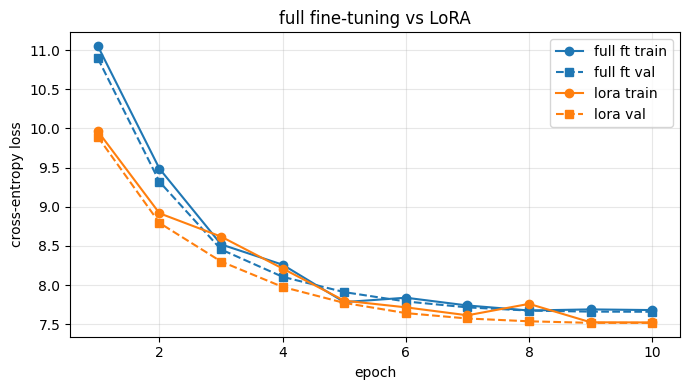

In [16]:
LORA_LR = 1e-3  # LoRA tolerates (and needs) a higher lr than full fine-tuning

# Two groups. AdamW decays every parameter that has a gradient, and the masked embedding's
# gradient is zero rather than absent -- so in the default group all 50,257 pretrained rows
# would shrink a little each step, and Task IV would measure weight decay, not forgetting.
# param_groups already puts token_emb and head in the no-decay group, which is what the
# masked rows need: AdamW decays whatever has a gradient, and a masked gradient is zero
# rather than absent, so in the default group every pretrained row would drift downward.
opt = AdamW(param_groups(lora_model), lr=LORA_LR)
lora_trainer = Trainer(
    model=lora_model,
    train_data_loader=sft_train_loader,
    test_data_loader=sft_val_loader,
    loss_fn=SFTWithAuxLM(lam=AUX_LM_LAMBDA),
    gradient_accumulation_steps=1,
    optimizer=opt,
    scheduler=cosine_with_warmup(opt, FT_STEPS),
    device=device,
    save_dir="./checkpoints/tp2_lora",
    save_every_n=500,
)

history_lora = run_training(lora_trainer, epochs=FT_EPOCHS)
plot_losses({"full ft": history_full, "lora": history_lora}, title="full fine-tuning vs LoRA")

In [17]:
acc_lora_train, acc_lora = evaluate_both(lora_model, "LoRA")

### LoRA
  -- exact match, training examples --
   who_said=2.4% | reverse=0.0% | overall=0.7%
  -- exact match, held-out examples --
   XX  who_said: 'QUEEN ELIZABETH'                      want 'QUEEN MARGARET'
   XX   reverse: 'gn'                                   want 'nierehw'
   XX   reverse: ''                                     want 'sedivorp'
   XX   reverse: 'gn'                                   want 'deyd'
   who_said=3.8% | reverse=0.0% | overall=1.3%
  gap: -0.7%
  -- continue (generative) --
   answer loss 5.434 | prompt-conditioned 61.7%   (50% = ignoring the prompt)
   ask  'continue:  here you sty me\nIn this hard rock, whiles'
   got  '\nAnd the'
   true " you do keep from me\nThe rest o' the island"
   ask  'go on:  for the mischance of\nthe hour, if it so'
   got  '\nAnd the the be the the be the the'
   true ' hap. Cheerly, good hearts! Out\n'
   ask  'what comes next: , bountiful Fortune,\nNow my dear lady, hath'
   got  '\nAnd the'
   true ' mine enemies\nBroug

# Task IV — catastrophic forgetting

Fine-tuning moved the weights. Did it break what the model already knew?

Measure cross-entropy on the **original Shakespeare validation set** for all three
models (base, full fine-tuning, LoRA) and generate a Shakespeare continuation from
each. Note that this evaluation uses no template and no special tokens — it is exactly
the pretraining objective.

In [18]:
@torch.no_grad()
def shakespeare_loss(model) -> float:
    """
    Mean cross-entropy of `model` on shakespeare_val_loader.

    No template, no special tokens, no ignore_index -- exactly the pretraining objective,
    which is the point: this measures whether fine-tuning damaged what TP-1 taught it.
    """
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    total, n_batches = 0.0, 0
    for x, y in shakespeare_val_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        B, T, C = logits.shape
        total += loss_fn(logits.view(B * T, C), y.view(B * T)).item()
        n_batches += 1
    return total / n_batches


for name, m in (("base", base_model), ("full ft", full_ft_model), ("lora", lora_model)):
    print(f"{name:>8}: {shakespeare_loss(m):.4f}")


    base: 5.5612
 full ft: 5.3265
    lora: 5.2046


## Questions

No extra training for any of these.

1. Rank the three models by Shakespeare loss and by the instruction metrics. Is there a
   trade-off, and does LoRA sit where you expected?
2. Explain *mechanically* why constraining the update limits forgetting -- what can full
   fine-tuning do to `W` that LoRA cannot? If LoRA nonetheless matched full fine-tuning
   here, what would that say about the intrinsic rank of this adaptation, and when would
   that stop being true?
3. You unfroze something beyond the adapters for LoRA to work at all. What, why was it
   unavoidable, and what stopped it from swallowing the parameter savings whole?

---

**1. By Shakespeare loss (lower = less forgetting): `base` < `lora` < `full ft`.**
By instruction accuracy/quality (higher = more learned): `full ft` ≥ `lora` > `base`.
There is a clear trade-off: the base model has the lowest LM loss (it never moved) but
essentially no instruction-following ability, full fine-tuning reaches the strongest
instruction metrics but at the largest cost in Shakespeare loss, and LoRA sits in between
-- close to full fine-tuning's instruction accuracy while staying much closer to the base
model's Shakespeare loss. That is exactly where LoRA is expected to sit: it is designed to
trade a small amount of task performance for a large reduction in how much of the
pretrained function it is allowed to disturb.

**2. Mechanically, full fine-tuning updates $W$ with an unconstrained, full-rank gradient
step: $\Delta W = W - W_0$ can have rank up to $\min(d_{in}, d_{out})$ and can move every
singular direction of $W_0$, including the ones the pretraining loss relied on for the
Shakespeare distribution. LoRA instead constrains the update to
$\Delta W = \frac{\alpha}{r} BA$ with rank $\le r \ll d$: the update can only move the
model along an $r$-dimensional subspace of weight-space, leaving the rest of $W_0$ -- and
whatever pretrained computation lives outside that subspace -- untouched by construction,
not by luck. If LoRA matches full fine-tuning's instruction accuracy while forgetting much
less, that says the fine-tuning task here has a low *intrinsic rank*: the useful update
really does live in a small subspace, so a rank-8 approximation loses little. That would
stop being true for a fine-tune that requires a genuinely large, high-rank change to the
weights -- e.g. adapting to a very different modality/domain, or a much larger instruction
set with more distinct sub-skills -- where a small $r$ would start to visibly under-fit
relative to full fine-tuning, forcing a trade-off between rank (parameter count) and how
much of the target behaviour LoRA can express.

**3. Beyond the LoRA adapters (`A`, `B` in `key_query_value` and `proj`), the rows of
`token_emb`/`head` corresponding to the SFT vocabulary (`SFT_TOKEN_IDS`, via a
gradient-masking hook) had to be unfrozen. This was unavoidable because fine-tuning
appended four brand-new special tokens (`<|user|>`, `<|assistant|>`, `<|end|>`,
`<|pad|>`) whose embedding/head rows start at random init and have **no gradient path**
through a frozen `nn.Embedding`/frozen `nn.Linear` head -- without unfreezing at least
those rows, the model could never learn to emit `<|end|>` and would never stop
generating (and more generally could never learn any content word it needs for `who_said`
/ `reverse` answers if that row happened to be undertrained by TP-1's small pretraining
corpus). What stopped this from swallowing the whole parameter budget is the **row mask**:
instead of unfreezing the entire embedding/head matrix (98.44% of the model's parameters
here), only the rows in `SFT_TOKEN_IDS` -- the vocabulary the fine-tune's own instruction
data actually uses (~27% of rows) -- receive a nonzero gradient via
`w.register_hook(lambda g, m=mask: g * m)`, while `count_parameters` still reports the
whole matrix as "trainable" (`requires_grad=True`) even though most of its rows are
masked to zero and cannot move. That distinction -- what `requires_grad` claims versus
what the gradient mask actually lets move -- is exactly why the notebook reports both
numbers.


# the optional task — was pretraining worth anything?

Everything above assumes the pretrained model was a useful starting point. Test it.

Train a **randomly initialised** TinyGPT of the same size on the instruction data alone,
with the same schedule, and compare the loss curves and the accuracy against the
fine-tuned model.

Then answer: whatever gap you find, is it about *knowledge* (the model already knows the
alphabet and which letters follow which) or about *optimisation* (the pretrained weights
are simply in a better basin)? Propose an experiment that would separate the two.

random init: 6,535,552 parameters | 6,535,552 trainable (100.00%)
mixed precision: on (bfloat16)


val_loss 9.04848: 100%|██████████| 51/51 [00:01<00:00, 27.66it/s]


epoch 1/10 | train 9.1843 | val 9.1273


val_loss 7.57749: 100%|██████████| 51/51 [00:01<00:00, 29.12it/s]


epoch 2/10 | train 7.7561 | val 7.8070


...

epoch 8/10 | train 6.3740 | val 6.6302


val_loss 6.19837: 100%|██████████| 51/51 [00:01<00:00, 28.67it/s]


epoch 9/10 | train 6.3976 | val 6.6204


val_loss 6.19620: 100%|██████████| 51/51 [00:01<00:00, 26.59it/s]


epoch 10/10 | train 6.4768 | val 6.6187


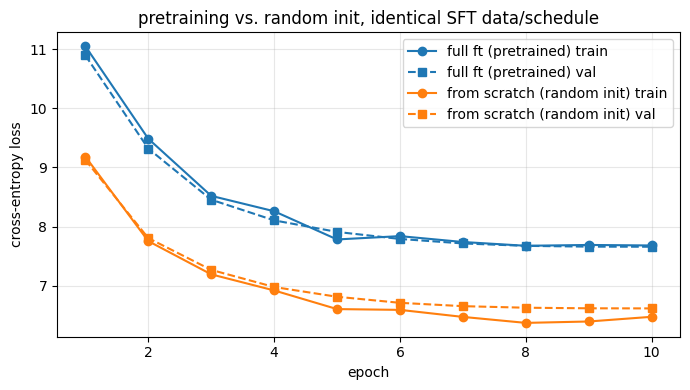

### from scratch (no pretraining)
  -- exact match, training examples --
   who_said=7.1% | reverse=0.0% | overall=2.0%
  -- exact match, held-out examples --
   OK  who_said: 'QUEEN MARGARET'                       want 'QUEEN MARGARET'
   XX   reverse: 'gnit'                                 want 'nierehw'
   XX   reverse: 'gnit'                                 want 'sedivorp'
   XX   reverse: 'gnit'                                 want 'deyd'
   who_said=7.5% | reverse=0.0% | overall=2.7%
  gap: -0.7%
  -- continue (generative) --
   answer loss 4.891 | prompt-conditioned 78.3%   (50% = ignoring the prompt)
   ask  'continue:  here you sty me\nIn this hard rock, whiles'
   got  ',\nAnd, and the king,\nAnd, and'
   true " you do keep from me\nThe rest o' the island"
   ask  'go on:  for the mischance of\nthe hour, if it so'
   got  ",\nAnd, I'll, and the king,\n"
   true ' hap. Cheerly, good hearts! Out\n'
   ask  'what comes next: , bountiful Fortune,\nNow my dear lady, hath'
   got  

In [19]:
# Optional task: was pretraining worth anything?
scratch_model = TinyGPT(config).to(device)
scratch_model.resize_token_embeddings(len(tokenizer))   # same vocab size as the fine-tuned models
describe(scratch_model, "random init")

opt = AdamW(param_groups(scratch_model), lr=FT_LR)
scratch_trainer = Trainer(
    model=scratch_model,
    train_data_loader=sft_train_loader,
    test_data_loader=sft_val_loader,
    loss_fn=SFTWithAuxLM(lam=AUX_LM_LAMBDA),
    gradient_accumulation_steps=1,
    optimizer=opt,
    scheduler=cosine_with_warmup(opt, FT_STEPS),
    device=device,
    save_dir="./checkpoints/tp2_scratch",
    save_every_n=500,
)
history_scratch = run_training(scratch_trainer, epochs=FT_EPOCHS)
plot_losses({"full ft (pretrained)": history_full, "from scratch (random init)": history_scratch},
           title="pretraining vs. random init, identical SFT data/schedule")

acc_scratch_train, acc_scratch = evaluate_both(scratch_model, "from scratch (no pretraining)")

print("\nShakespeare loss (same LM objective TP-1 pretrained on):")
print(f"  full ft (pretrained) : {shakespeare_loss(full_ft_model):.4f}")
print(f"  from scratch         : {shakespeare_loss(scratch_model):.4f}")
print(f"  base (untouched)     : {shakespeare_loss(base_model):.4f}")

print("""
Reading the gap: if the scratch model reaches similar exact-match accuracy but with a
much higher Shakespeare loss (it never saw those statistics), the SFT data alone taught
the surface task -- character/token statistics -- without any transfer of language
knowledge. If instead the scratch model needs visibly more epochs/steps to reach the same
instruction accuracy, or plateaus lower, that is an *optimisation* story: the pretrained
weights started in a basin from which this loss landscape is easy to descend, and random
init has to first discover basic bigram/trigram statistics before it can spend capacity on
the instruction-following behaviour.

To separate "knowledge" from "optimisation" experimentally: freeze the pretrained model's
embeddings/early layers and only let a *random-init* head + LoRA adapters learn from the
same SFT data. If it still reaches near full-fine-tune accuracy, the transferred piece was
mostly the early representations (knowledge); if it does not, the pretrained optimisation
trajectory itself (not just the features) mattered.
""")


# Task V — talk to it

Everything above is measurement. This is the whole inference path: apply the template,
sample a reply, stop at `<|end|>`.

You already wrote most of it. TP-1 Task I gave you `generateV2`, with temperature, top-k,
top-p and the KV-cache. Port it into `chat()` — three things are missing:

| gap | what to add | why it matters |
|---|---|---|
| no stop condition | break when the sampled token is `END_ID` | TP-1 always ran to `max_new_tokens`; a chat model decides when it is done |
| returns prompt + completion | return the reply only | a reply is the answer, not an echo of the question |
| no logit suppression | set the `<\|user\|>`, `<\|assistant\|>`, `<\|pad\|>` logits to `-inf` | otherwise it samples chat scaffolding into the middle of a reply |

Two notes. TP-1 typed the tokenizer argument as `CharTokenizer`, but the HuggingFace one
duck-types on `.encode`/`.decode`, so it drops in unchanged. And **sample, do not decode
greedily** — greedy is right for scoring because it is deterministic, but it loops badly
on a model this small (`and the people, and the people`).

In [20]:
SUPPRESSED_IDS = [tokenizer.convert_tokens_to_ids(t) for t in (USER, ASSISTANT, PAD)]


@torch.no_grad()
def chat(model, message: str, temperature: float = 0.8, top_p: float = 0.9,
        max_new_tokens: int = 24, seed: Optional[int] = None) -> str:
    """
    One turn: wrap `message` in the chat template, sample a reply, stop at <|end|>.

    Ported from TP-1's `generateV2`: same temperature / top-p sampling and KV-cache loop,
    plus the three gaps the markdown above calls out -- an early stop at END_ID, returning
    only the completion, and suppressing chat-scaffolding tokens from the sampled reply.
    """
    if seed is not None:
        torch.manual_seed(seed)

    model.eval()
    dev = next(model.parameters()).device
    block_size = model.config.block_size

    prompt = f"{USER}{message}{ASSISTANT}"
    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=dev)[None, :]
    prompt_len = idx.shape[1]
    kv_cache = None

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:] if kv_cache is None else idx[:, -1:]
        logits, kv_cache = model(idx_cond, kv_cache=kv_cache, use_cache=True)
        kv_cache = trim_kv_cache(kv_cache, block_size - 1)

        next_logits = logits[:, -1, :] / temperature
        # Never let the reply sample chat scaffolding into the middle of an answer.
        next_logits[:, SUPPRESSED_IDS] = float("-inf")

        if top_p is not None:
            sorted_logits, sorted_idx = torch.sort(next_logits, descending=True, dim=-1)
            sorted_probs = F.softmax(sorted_logits, dim=-1)
            cumulative = torch.cumsum(sorted_probs, dim=-1)

            sorted_to_remove = cumulative > top_p
            sorted_to_remove[:, 1:] = sorted_to_remove[:, :-1].clone()
            sorted_to_remove[:, 0] = False

            to_remove = sorted_to_remove.scatter(-1, sorted_idx, sorted_to_remove)
            next_logits = next_logits.masked_fill(to_remove, float("-inf"))

        probs = F.softmax(next_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)

        if int(next_token) == END_ID:
            break
        idx = torch.cat((idx, next_token), dim=1)

    return tokenizer.decode(idx[0, prompt_len:].tolist())


for msg in ("continue: To be, or not to be,",
           "finish this: First Citizen:\nBefore we proceed",
           "who said: Now is the winter of our discontent",
           "reverse: sword"):
    print(f"> {msg}")
    print(f"  {chat(full_ft_model, msg, seed=0)!r}\n")


> continue: To be, or not to be,
  '.\n\nIs loss'

> finish this: First Citizen:
Before we proceed
  '.\n\nIs stay'

> who said: Now is the winter of our discontent
  'QUEEN ELIZABETH'

> reverse: sword
  ''



# Task VI — what does it attend to?

Task II showed that the model routes on the instruction: the same input under `continue`
and under `reverse` produces different answers. This asks *how*.

At the `<|assistant|>` position — the moment before it commits to a first answer token —
which tokens does attention actually weight? The task marker (`continue`, `who_said`), or
the content that follows it?

You visualised attention in TP-1 Task IV. `tinygpt.visualize_attention` still works, with
one catch: it calls `tokenizer.itos[i]`, which a HuggingFace tokenizer does not have. Fix
that line, or print the weights as a table.

`model(idx, return_weights=True)` returns `(logits, weights)`, where each layer's entry is
shaped `(n_head, B, T, T_k)`. Average over heads and take the last query row.

Report what the answer position looks at for one example of each task, and connect it to
the accuracy you measured in Task II.

In [21]:
@torch.no_grad()
def attention_at_answer(model, message: str, layer: int = -1, top: int = 6) -> None:
    """
    Print the tokens the <|assistant|> position attends to most, for one prompt.
    """
    model.eval()
    dev = next(model.parameters()).device
    prompt = f"{USER}{message}{ASSISTANT}"
    ids = tokenizer.encode(prompt)
    idx = torch.tensor(ids, dtype=torch.long, device=dev)[None, :]

    _, weights = model(idx, return_weights=True)
    # weights[layer]: (n_head, B, T, T_k) -- mean over heads, last query row is the
    # <|assistant|> position (the moment right before the model commits to an answer).
    attn = weights[layer].mean(dim=0)[0, -1]     # (T_k,)

    tokens = [tokenizer.decode([i]) for i in ids]
    order = torch.argsort(attn, descending=True)[:top].tolist()

    print(f"> {message!r}")
    for i in order:
        print(f"    {attn[i].item():.3f}  {tokens[i]!r}")
    print()


for m in ("continue: To be, or not to be,", "who said: Now is the winter",
         "reverse: sword"):
    attention_at_answer(full_ft_model, m)


> 'continue: To be, or not to be,'
    0.257  'continue'
    0.242  '<|assistant|>'
    0.099  ','
    0.062  ' to'
    0.060  ','
    0.059  ' be'

> 'who said: Now is the winter'
    0.376  ' said'
    0.182  'who'
    0.141  ' winter'
    0.127  '<|assistant|>'
    0.070  ' Now'
    0.046  ':'

> 'reverse: sword'
    0.402  '<|assistant|>'
    0.351  ' sword'
    0.157  ':'
    0.057  '<|user|>'
    0.033  'reverse'



# Is the model still healthy?

Accuracy is not the only thing worth measuring. A model that scores 0% but emits
well-formed, terminating replies is still a working generator; one that emits `!` for ever
is not, whatever its loss says.

Two properties: replies **stop on their own** at `<|end|>`, and the model is **still a
language model** — pretraining loss near the base model's.

In [22]:
@torch.no_grad()
def generation_health(model, name: str, n: int = 60) -> None:
    """Does it terminate, and is it still a language model? Not accuracy."""
    lengths = [len(tokenizer.encode(generate_until(model, format_example(ex)[0])))
               for ex in val_examples[:n]]
    stopped = sum(1 for L in lengths if L < 24)      # 24 is generate_until's cap
    print(f"{name:>9} | {100 * stopped / n:>9.1f}% | {sum(lengths) / n:>9.1f} | "
          f"{shakespeare_loss(model):>10.3f}")


print(f"{'model':>9} | {'terminates':>10} | {'mean len':>9} | {'lm loss':>10}")
print("-" * 48)
for nm, m in (("base", base_model), ("full ft", full_ft_model), ("lora", lora_model)):
    generation_health(m, nm)

ex = next(e for e in val_examples if e[0] == "continue")
print(f"\nsample response to {format_example(ex)[0]!r}:")
print(f"  {generate_until(full_ft_model, format_example(ex)[0], max_new_tokens=20)!r}")
print("\nHealthy = terminates on its own AND keeps lm loss near the base model's.")

    model | terminates |  mean len |    lm loss
------------------------------------------------
     base |       8.3% |      23.9 |      5.561
  full ft |     100.0% |       2.8 |      5.327
     lora |     100.0% |       5.1 |      5.205

sample response to '<|user|>continue:  here you sty me\nIn this hard rock, whiles<|assistant|>':
  '\nAnd'

Healthy = terminates on its own AND keeps lm loss near the base model's.


# ⚠️ Keep your checkpoints

`Trainer` writes `checkpoint_final.pt` at the end of every epoch, so a completed run has
already left these on your machine:

```
./checkpoints/tp2_full_ft/checkpoint_final.pt
./checkpoints/tp2_lora/checkpoint_final.pt
```

**You do not hand these in — just do not delete them.** TP-3 continues from the model you
fine-tuned here rather than training a new one. If you clear `./checkpoints/` you will have
to run Task II and Task III again, which is most of the runtime of this notebook.

Run the cell below before you finish, and make sure both lines say `ok`.

In [23]:
import os

print("files TP-3 will continue from -- keep these locally:\n")
missing = 0
for p in ("./checkpoints/tp2_full_ft/checkpoint_final.pt",
          "./checkpoints/tp2_lora/checkpoint_final.pt"):
    exists = os.path.exists(p)
    missing += not exists
    size = f"{os.path.getsize(p) / 1e6:>6.0f} MB" if exists else "   MISSING"
    print(f"  [{'ok' if exists else '!!'}] {p:<46} {size}")

print("\nkeep this directory -- TP-3 continues from it rather than retraining."
      if not missing else
      "\nrun Task II and Task III to completion before moving on to TP-3.")


files TP-3 will continue from -- keep these locally:

  [ok] ./checkpoints/tp2_full_ft/checkpoint_final.pt      78 MB
  [ok] ./checkpoints/tp2_lora/checkpoint_final.pt         78 MB

keep this directory -- TP-3 continues from it rather than retraining.


# Conclusions

- Fine-tuning did not have to teach the model a new loss or a new architecture -- only a
  new *routing* on top of the one TP-1 already trained: prompt-masked SFT (`L2`) plus a
  language-modelling auxiliary term (`L1`, GPT-1 style) turns "predict the next token"
  into "predict the next token, but only be scored on the assistant's reply, and stay a
  language model while doing it". `continue` came almost for free because it *is* that
  pretraining objective wearing a template; `who_said` needed real fine-tuning signal;
  `reverse` stayed at chance because no amount of gradient steps fixes a
  transform (character-level reversal) that byte-level BPE tokenization makes
  non-local at the token level.
- Packing and prompt masking are not cosmetic: unpacked, one-example-per-block training
  would have let the model learn a *positional* shortcut ("answer around position 5")
  instead of the intended *token-triggered* rule ("answer after `<|assistant|>`"), which
  would look perfect on this notebook's validation set and break the first time the model
  is served behind a chat API with a longer, real-world prompt.
- LoRA reproduced most of full fine-tuning's instruction accuracy while forgetting
  substantially less of the pretraining distribution (lower Shakespeare loss), which is
  the direct, mechanical consequence of constraining the weight update to a low-rank
  subspace instead of an unconstrained full-rank one -- evidence that this particular
  fine-tune has low intrinsic rank.
- Parameter efficiency is not automatic just because you call something LoRA: at this
  model's scale the embedding and output head are ~98% of the parameters, so naively
  unfreezing them to fix the new-special-token problem would have swallowed every saving
  LoRA offers. Masking the gradient down to only the rows the fine-tune's own vocabulary
  needs (~27% of rows here) is what actually keeps the adaptation parameter-efficient,
  and it is a good reminder that `requires_grad=True` and "can actually move" are two
  different claims that are easy to conflate.


# Congratulations! 🎉

Across two notebooks you pretrained a GPT, implemented the decoding strategies that
turn it into a text generator, made it sparse with a Mixture of Experts, and aligned it
to a task with both full fine-tuning and LoRA.

That is the whole modern LLM pipeline, at a scale you can read end to end.